In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import matplotlib.pyplot as plt
from wordcloud import WordCloud, STOPWORDS




BASE_PATH = "/mnt/vast-kisski/projects/kisski_tegami"
INPUT_PATH = f"{BASE_PATH}/datasets/TG"
OUTPUT_PATH = f"{BASE_PATH}/datasets/TG/labels"

# Summary of weak labels
## TG Unified 

In [3]:
df = pd.read_parquet(f"{INPUT_PATH}/labels/TG_sentiment.parquet")
df

,message_id,sentiment
0,cfa932a6-f24b-44e1-b08d-a102708877f6,negative
2,d79f5f15-0371-431f-ad0c-0945b841acfa,positive
3,f76b1d68-b78e-4527-b0b8-e8000d3d80d6,negative
4,acf342a4-e276-4b56-8a61-947f57fe7557,negative
6,0dceecc2-5746-4315-b74e-208747793a7c,negative
...,...,...
44704263,f5c85c26-aa50-4218-911e-2222e01ca9a0,neutral
44704265,b1fd9da1-bce6-41d1-8cd5-3f22f0391c26,neutral
44704266,d12c58cc-7794-4643-9638-3955152be4f7,neutral
44704267,7a70b7a4-3244-4cc4-af23-9aacaf2ef8b8,neutral


In [4]:
tasks = ["hate","lexbias","sexism"]
# Init target df
df = pd.read_parquet(f"{INPUT_PATH}/labels/TG_sentiment.parquet")
for task in tasks:
    path = f"{INPUT_PATH}/labels/TG_{task}.parquet"
    temp_df = pd.read_parquet(path)
    df = pd.merge(df, temp_df, on="message_id", how="inner")
df


,message_id,sentiment,hate,lexbias,sexism
0,cfa932a6-f24b-44e1-b08d-a102708877f6,negative,normal,biased,LABEL_0
1,d79f5f15-0371-431f-ad0c-0945b841acfa,positive,normal,biased,LABEL_0
2,f76b1d68-b78e-4527-b0b8-e8000d3d80d6,negative,normal,biased,LABEL_0
3,acf342a4-e276-4b56-8a61-947f57fe7557,negative,offensive,biased,LABEL_1
4,0dceecc2-5746-4315-b74e-208747793a7c,negative,offensive,biased,LABEL_0
...,...,...,...,...,...
15195861,f5c85c26-aa50-4218-911e-2222e01ca9a0,neutral,normal,neutral,LABEL_0
15195862,b1fd9da1-bce6-41d1-8cd5-3f22f0391c26,neutral,normal,neutral,LABEL_0
15195863,d12c58cc-7794-4643-9638-3955152be4f7,neutral,normal,neutral,LABEL_0
15195864,7a70b7a4-3244-4cc4-af23-9aacaf2ef8b8,neutral,normal,neutral,LABEL_0


In [5]:
tg_df = pd.read_parquet(f"{INPUT_PATH}/TG_unified.parquet")
tg_df.head()

,channel_id,message,topic,message_id,char_len,language
0,1150106827,Not Glory crying about her mom taking away her...,Religion,cfa932a6-f24b-44e1-b08d-a102708877f6,75,en
2,1150106827,"Oh boy, looks like all Mercy lhemeson ( Glory'...",Religion,d79f5f15-0371-431f-ad0c-0945b841acfa,138,en
3,1150106827,When glorilla tries to say it's not a victim. ...,Religion,f76b1d68-b78e-4527-b0b8-e8000d3d80d6,64,en
4,1150106827,Glory fucking a plunger cause no men wants her...,Religion,acf342a4-e276-4b56-8a61-947f57fe7557,70,en
6,1150106827,Lmfaooo Glory's family are bunch of retards,Religion,0dceecc2-5746-4315-b74e-208747793a7c,43,en


In [6]:
df = pd.merge(tg_df,df,how="inner", on="message_id")
mappings = {"LABEL_0": "NOT SEXIST", "LABEL_1": "SEXIST"}
df["sexism"] = df["sexism"].map(mappings)
df.head()


,channel_id,message,topic,message_id,char_len,language,sentiment,hate,lexbias,sexism
0,1150106827,Not Glory crying about her mom taking away her...,Religion,cfa932a6-f24b-44e1-b08d-a102708877f6,75,en,negative,normal,biased,NOT SEXIST
1,1150106827,"Oh boy, looks like all Mercy lhemeson ( Glory'...",Religion,d79f5f15-0371-431f-ad0c-0945b841acfa,138,en,positive,normal,biased,NOT SEXIST
2,1150106827,When glorilla tries to say it's not a victim. ...,Religion,f76b1d68-b78e-4527-b0b8-e8000d3d80d6,64,en,negative,normal,biased,NOT SEXIST
3,1150106827,Glory fucking a plunger cause no men wants her...,Religion,acf342a4-e276-4b56-8a61-947f57fe7557,70,en,negative,offensive,biased,SEXIST
4,1150106827,Lmfaooo Glory's family are bunch of retards,Religion,0dceecc2-5746-4315-b74e-208747793a7c,43,en,negative,offensive,biased,NOT SEXIST


In [ ]:
# Store TG-weak-label-all
#df.to_parquet(f"{OUTPUT_PATH}/TG-weak-label-all.parquet")

### WordClouds

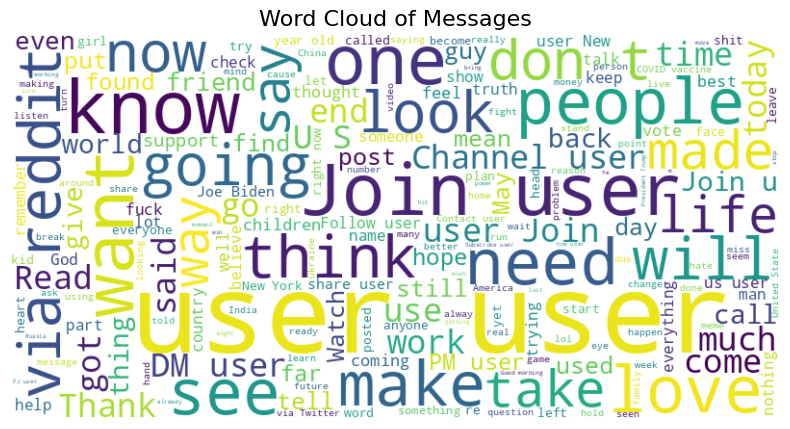

In [ ]:
# Combine all messages into a single string
text = " ".join(df["message"].astype(str))

# Define stopwords (you can add custom ones)
stopwords = set(STOPWORDS)

# Generate the word cloud
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white",
    stopwords=stopwords,
    colormap="viridis"  # you can try 'plasma', 'inferno', 'coolwarm', etc.
).generate(text)

# Plot the word cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of Messages", fontsize=16)
plt.show()

## Aggregate shares of labeled messages

In [7]:
# Function
def bar_chart(counts, task):
    #plt.figure(figsize=(10, 6))
    plt.figure(figsize=(14, 6)) 
    sns.barplot(data=counts, x="topic", y="percentage", hue=task)

    plt.title(f"Message Percentage by {task} and topic")
    plt.ylabel("Percentage (%)")
    plt.xlabel("Topic")
    plt.legend(title=task)
    #plt.xticks(rotation=45)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()
    plt.close()

def pie_chart(df, label):
    # Show distribution
    counts = df[label].value_counts()
    print(counts)
    # Create pie chart
    plt.figure(figsize=(6, 6))
    plt.pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=140)
    plt.title(f"Distribution of {label}")
    plt.axis('equal') 
    # Save figure
    #plt.savefig(f"src/{label}_dist.png")
    plt.show()
    plt.close()

def share_of_labels(df, task):

    # Make pie chart
    pie_chart(df, label=task)

    # Tabular distribution by topic
    counts = df.groupby(["topic", task]).agg(count=("message_id", "count"))
    counts["percentage"] = (counts["count"] / counts.groupby(level=0)["count"].transform("sum") * 100).round(2)
    print(counts)

    # Make Bar Plot
    bar_chart(counts, task)


sexism
NOT SEXIST    15079806
SEXIST          116060
Name: count, dtype: int64


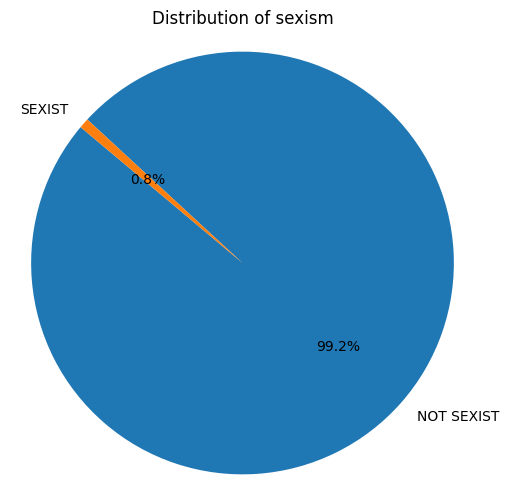

                                      count  percentage
topic                   sexism                         
Carding                 NOT SEXIST   684833       99.83
                        SEXIST         1176        0.17
Covid                   NOT SEXIST  1094811       99.64
                        SEXIST         3936        0.36
Crypto                  NOT SEXIST   822174       99.92
                        SEXIST          692        0.08
Entertainment           NOT SEXIST  1639166       99.58
                        SEXIST         6887        0.42
Extremists and radicals NOT SEXIST   335823       98.29
                        SEXIST         5857        1.71
Indian edu              NOT SEXIST   491047       99.95
                        SEXIST          226        0.05
Porn                    NOT SEXIST   451948       98.17
                        SEXIST         8422        1.83
Religion                NOT SEXIST  3537835       98.12
                        SEXIST        67881     

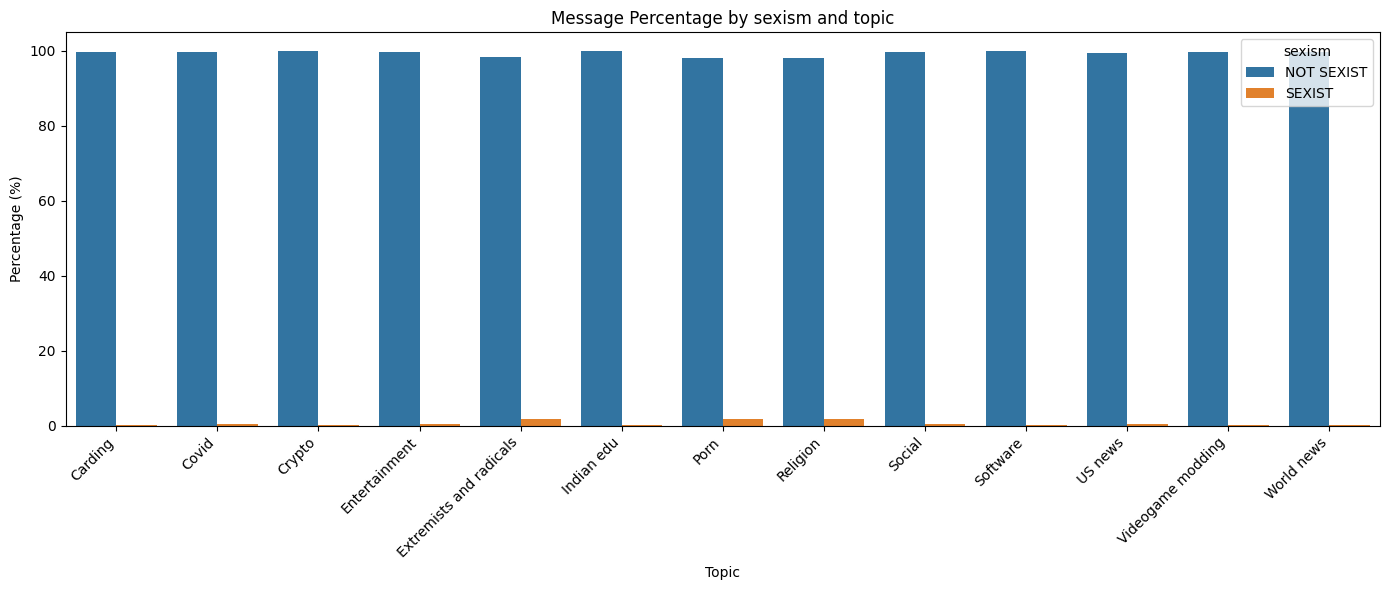

In [8]:
# Gender
share_of_labels(df, task="sexism")

hate
normal         14984339
offensive        173707
hate speech       37820
Name: count, dtype: int64


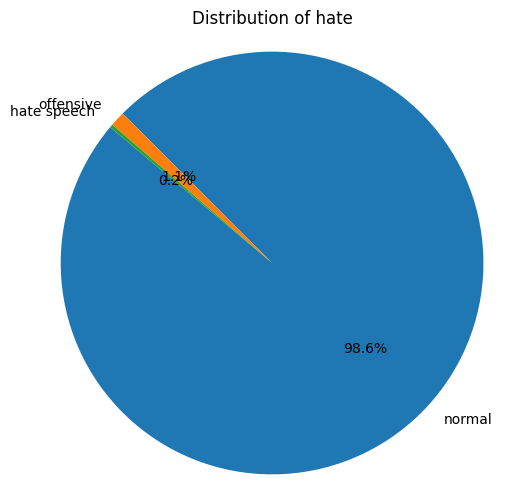

                                       count  percentage
topic                   hate                            
Carding                 hate speech      231        0.03
                        normal        684089       99.72
                        offensive       1689        0.25
Covid                   hate speech     2257        0.21
                        normal       1082592       98.53
                        offensive      13898        1.26
Crypto                  hate speech      577        0.07
                        normal        818862       99.51
                        offensive       3427        0.42
Entertainment           hate speech     1710        0.10
                        normal       1636328       99.41
                        offensive       8015        0.49
Extremists and radicals hate speech     7583        2.22
                        normal        315781       92.42
                        offensive      18316        5.36
Indian edu              hate sp

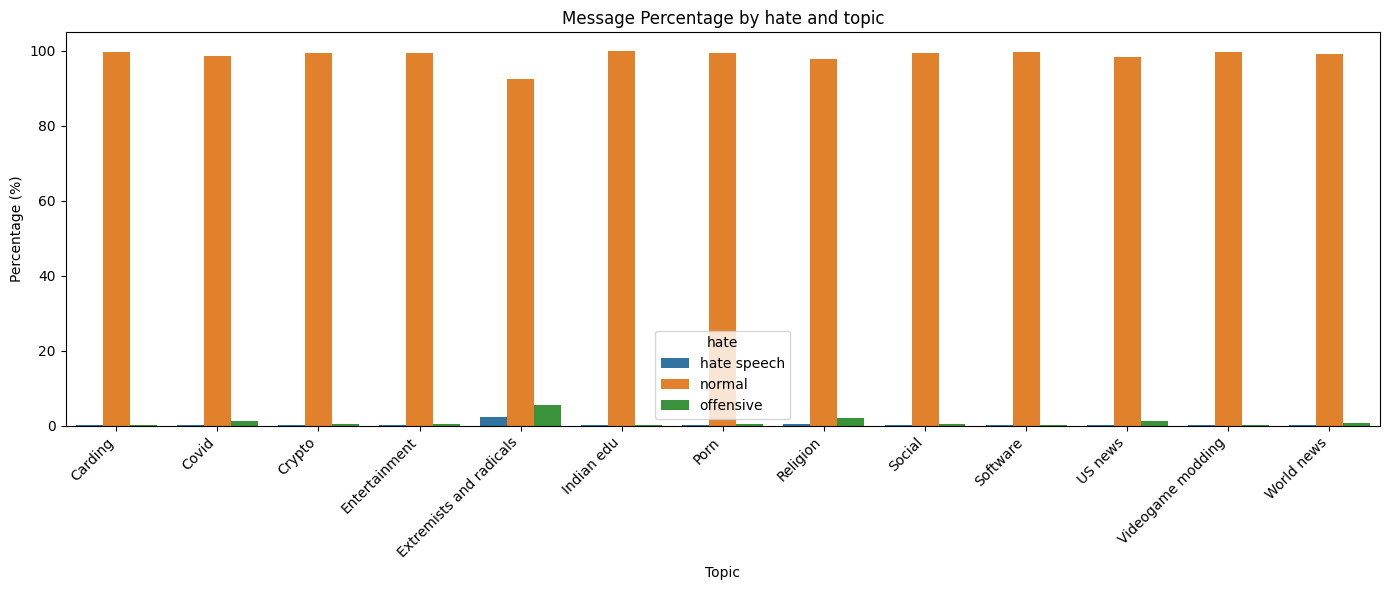

In [9]:
# Hatespeech
share_of_labels(df, task="hate")

sentiment
neutral     8837784
negative    3321003
positive    3037079
Name: count, dtype: int64


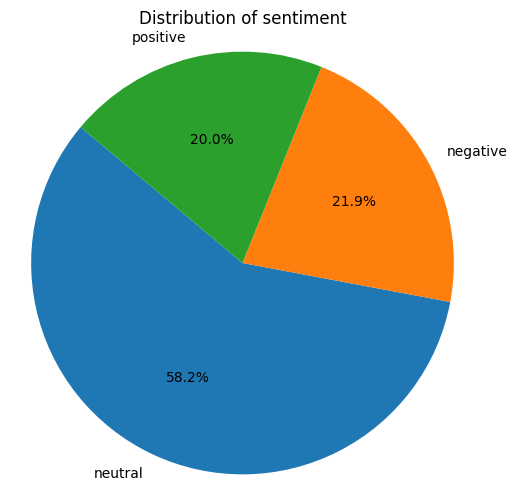

                                     count  percentage
topic                   sentiment                     
Carding                 negative     35061        5.11
                        neutral     433982       63.26
                        positive    216966       31.63
Covid                   negative    327941       29.85
                        neutral     593431       54.01
                        positive    177375       16.14
Crypto                  negative     71925        8.74
                        neutral     547190       66.50
                        positive    203751       24.76
Entertainment           negative    118727        7.21
                        neutral    1161363       70.55
                        positive    365963       22.23
Extremists and radicals negative    141255       41.34
                        neutral     157130       45.99
                        positive     43295       12.67
Indian edu              negative     26545        5.40
          

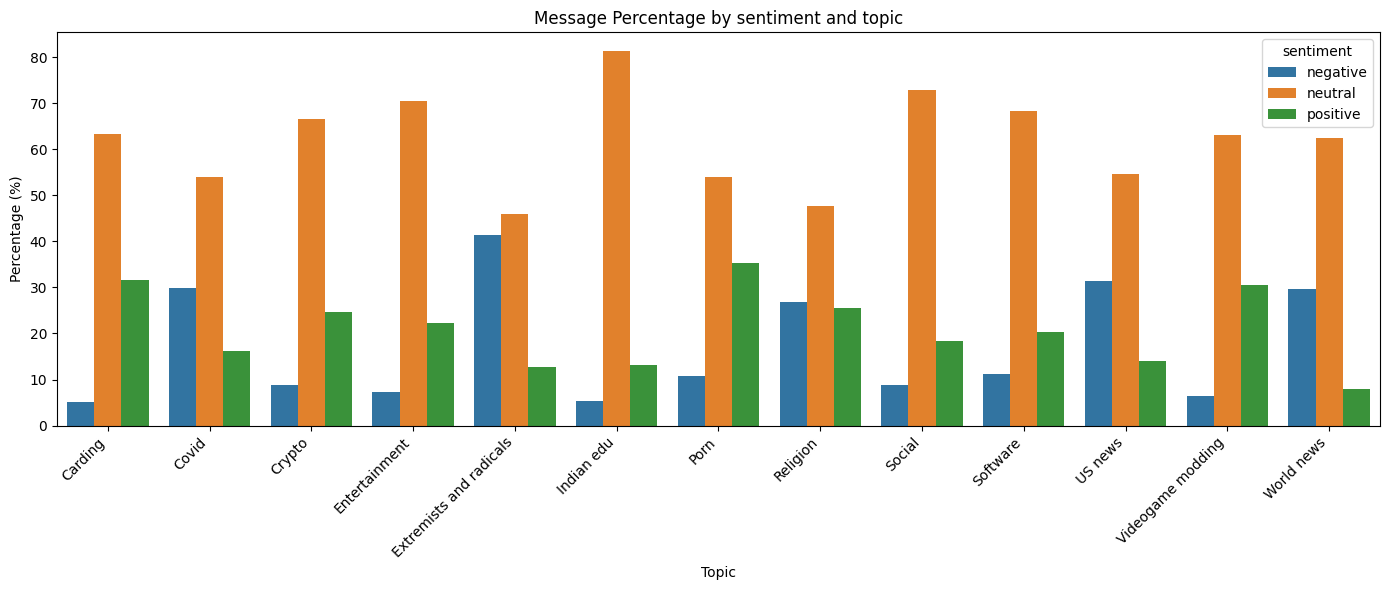

In [10]:
# Sentiment
share_of_labels(df, task="sentiment")

lexbias
neutral    10817868
biased      4377998
Name: count, dtype: int64


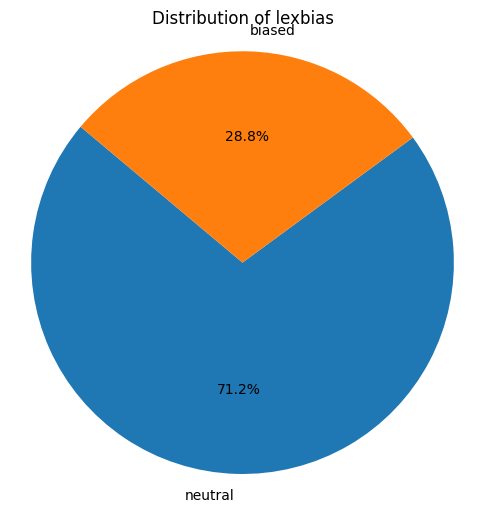

                                   count  percentage
topic                   lexbias                     
Carding                 biased    105444       15.37
                        neutral   580565       84.63
Covid                   biased    365805       33.29
                        neutral   732942       66.71
Crypto                  biased    124708       15.16
                        neutral   698158       84.84
Entertainment           biased    241589       14.68
                        neutral  1404464       85.32
Extremists and radicals biased    180122       52.72
                        neutral   161558       47.28
Indian edu              biased     29456        6.00
                        neutral   461817       94.00
Porn                    biased    130474       28.34
                        neutral   329896       71.66
Religion                biased   1410199       39.11
                        neutral  2195517       60.89
Social                  biased     37610      

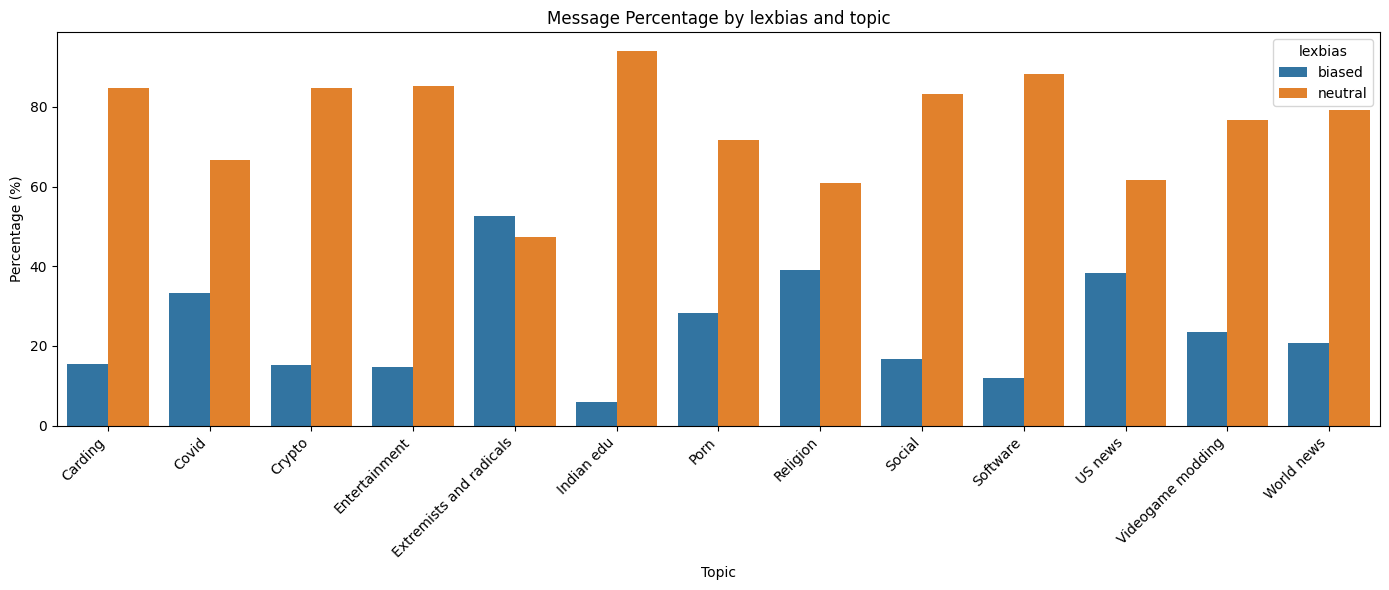

In [11]:
# Lexbias
share_of_labels(df, task="lexbias")

## Downsampling

In [12]:
# utils
def downsample(df, task):
    # Step 1: Count class sizes
    labels = df[task].unique()
    class_sizes = []
    for label in labels: 
        class_size = len(df[df[task] == label])
        class_sizes.append(class_size)

    downsample_size = min(class_sizes)

    ids_to_keep = []
    for label in labels:
        ids = (
            df[df[task] == label]
            .sample(n=downsample_size, random_state=42)["message_id"]
            .to_list()
        )
        ids_to_keep.extend(ids) 
    
    df = df[df["message_id"].isin(ids_to_keep)]
    print(len(df))
    print(df[task].value_counts())

    return df


In [ ]:
sexism_df = downsample(df, "sexism")

232120
sexism
SEXIST        116060
NOT SEXIST    116060
Name: count, dtype: int64


,channel_id,message,topic,message_id,char_len,language,sentiment,hate,lexbias,sexism
3,1150106827,Glory fucking a plunger cause no men wants her...,Religion,acf342a4-e276-4b56-8a61-947f57fe7557,70,en,negative,offensive,biased,SEXIST
9,1150106827,She's an ugly slut,Religion,23c9848d-ef31-4ee3-aae7-1b045f0420ca,18,en,negative,normal,biased,SEXIST
13,1150106827,"Which one is more disgusting, Muva gigantic ar...",Religion,d915727a-ff27-470f-9727-9b85fcbdc819,75,en,negative,normal,biased,SEXIST
45,1150106827,You guys can bleach your beautiful eyes with t...,Religion,5235f92e-f56f-4127-9561-3d960c797bb6,110,en,positive,normal,biased,SEXIST
49,1150106827,"Oh shit, who's that bitch",Religion,81e535df-940e-4ecc-8f13-1c61d9cce04e,25,en,negative,offensive,biased,SEXIST
...,...,...,...,...,...,...,...,...,...,...
15195428,1526807464,ALL SURPORTED BY @user THE OWNER C.E.O As we p...,Carding,90eee1e5-595b-45fc-a7ae-9bfa439ce55f,231,en,positive,normal,neutral,NOT SEXIST
15195685,1092173007,Jihadprim? Possibly... (OC),Religion,95c984d0-43cc-4d2e-b6e4-be065e464f7d,27,en,neutral,normal,biased,NOT SEXIST
15195697,1092173007,Everywhere Islam touches there are less whores,Religion,34ffeb48-8231-4135-9733-a345977244ee,46,en,neutral,offensive,biased,SEXIST
15195733,1092173007,Women can't drive because they 'have a quarter...,Religion,73fea813-c661-4e9a-ac06-c64561e257d8,237,en,negative,normal,neutral,SEXIST


In [14]:
hate_df = downsample(df, "hate")

113460
hate
offensive      37820
hate speech    37820
normal         37820
Name: count, dtype: int64


In [15]:
senti_df = downsample(df, "sentiment")

9111237
sentiment
negative    3037079
positive    3037079
neutral     3037079
Name: count, dtype: int64


In [16]:
lexbias_df = downsample(df, "lexbias")

8755996
lexbias
biased     4377998
neutral    4377998
Name: count, dtype: int64


#### With Topic filter

In [17]:
relevant_topics = ['Religion','US news','Covid','World news','Extremists and radicals','Social']
filtered_df = df[df["topic"].isin(relevant_topics)]
print(len(filtered_df))

10017548


In [18]:
for task in ["lexbias", "sentiment", "sexism", "hate"]:
    print(task)
    dummy_df = downsample(filtered_df, task)
    print("-------------------------")

lexbias


7130566
lexbias
biased     3565283
neutral    3565283
Name: count, dtype: int64
-------------------------
sentiment
5271834
sentiment
negative    1757278
positive    1757278
neutral     1757278
Name: count, dtype: int64
-------------------------
sexism
195142
sexism
SEXIST        97571
NOT SEXIST    97571
Name: count, dtype: int64
-------------------------
hate
103890
hate
offensive      34630
hate speech    34630
normal         34630
Name: count, dtype: int64
-------------------------


### Save balanced datasets without topic filter

In [22]:
# Sexism
sexism_df = sexism_df.drop(columns=["sentiment","hate","lexbias"])
sexism_df.to_parquet(f"{OUTPUT_PATH}/TG-sexism-balanced.parquet")
# Sentiment
senti_df = senti_df.drop(columns=["sexism","hate","lexbias"])
senti_df.to_parquet(f"{OUTPUT_PATH}/TG-sentiment-balanced.parquet")
# Hate
hate_df = hate_df.drop(columns=["sentiment","sexism","lexbias"])
hate_df.to_parquet(f"{OUTPUT_PATH}/TG-hate-balanced.parquet")
# Lexbias
lexbias_df = lexbias_df.drop(columns=["sentiment","hate","sexism"])
lexbias_df.to_parquet(f"{OUTPUT_PATH}/TG-lexbias-balanced.parquet")